# [LAB-10] 1-2. 로지스틱회귀 모듈화 - 연습문제

## 당신은 어느 야구팀의 전력분석 팀에 입사했습니다.  

요즘 에이스 신맵돌의 승리 확률을 예측해야 합니다.

팀 전력분석팀은 신맵돌이 등판한 240경기를 모아, 매 경기 그가 내준 실점과 그날 그가 승리투수가 됐는지(1) / 되지 못했는지(0)를 baseball 데이터셋으로 정리했습니다.

## 코드 작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 데이터 불러오기

In [2]:
origin = load_data("pitcher_wins")
origin.head()

📚 야구선수 신맵돌의 실점과 승리 여부를 기록한 데이터


,실점,승리여부
0,4,0
1,1,1
2,3,0
3,3,1
4,2,0


### 탐색적 데이터 분석

승리여부
0    128
1    112
Name: count, dtype: int64


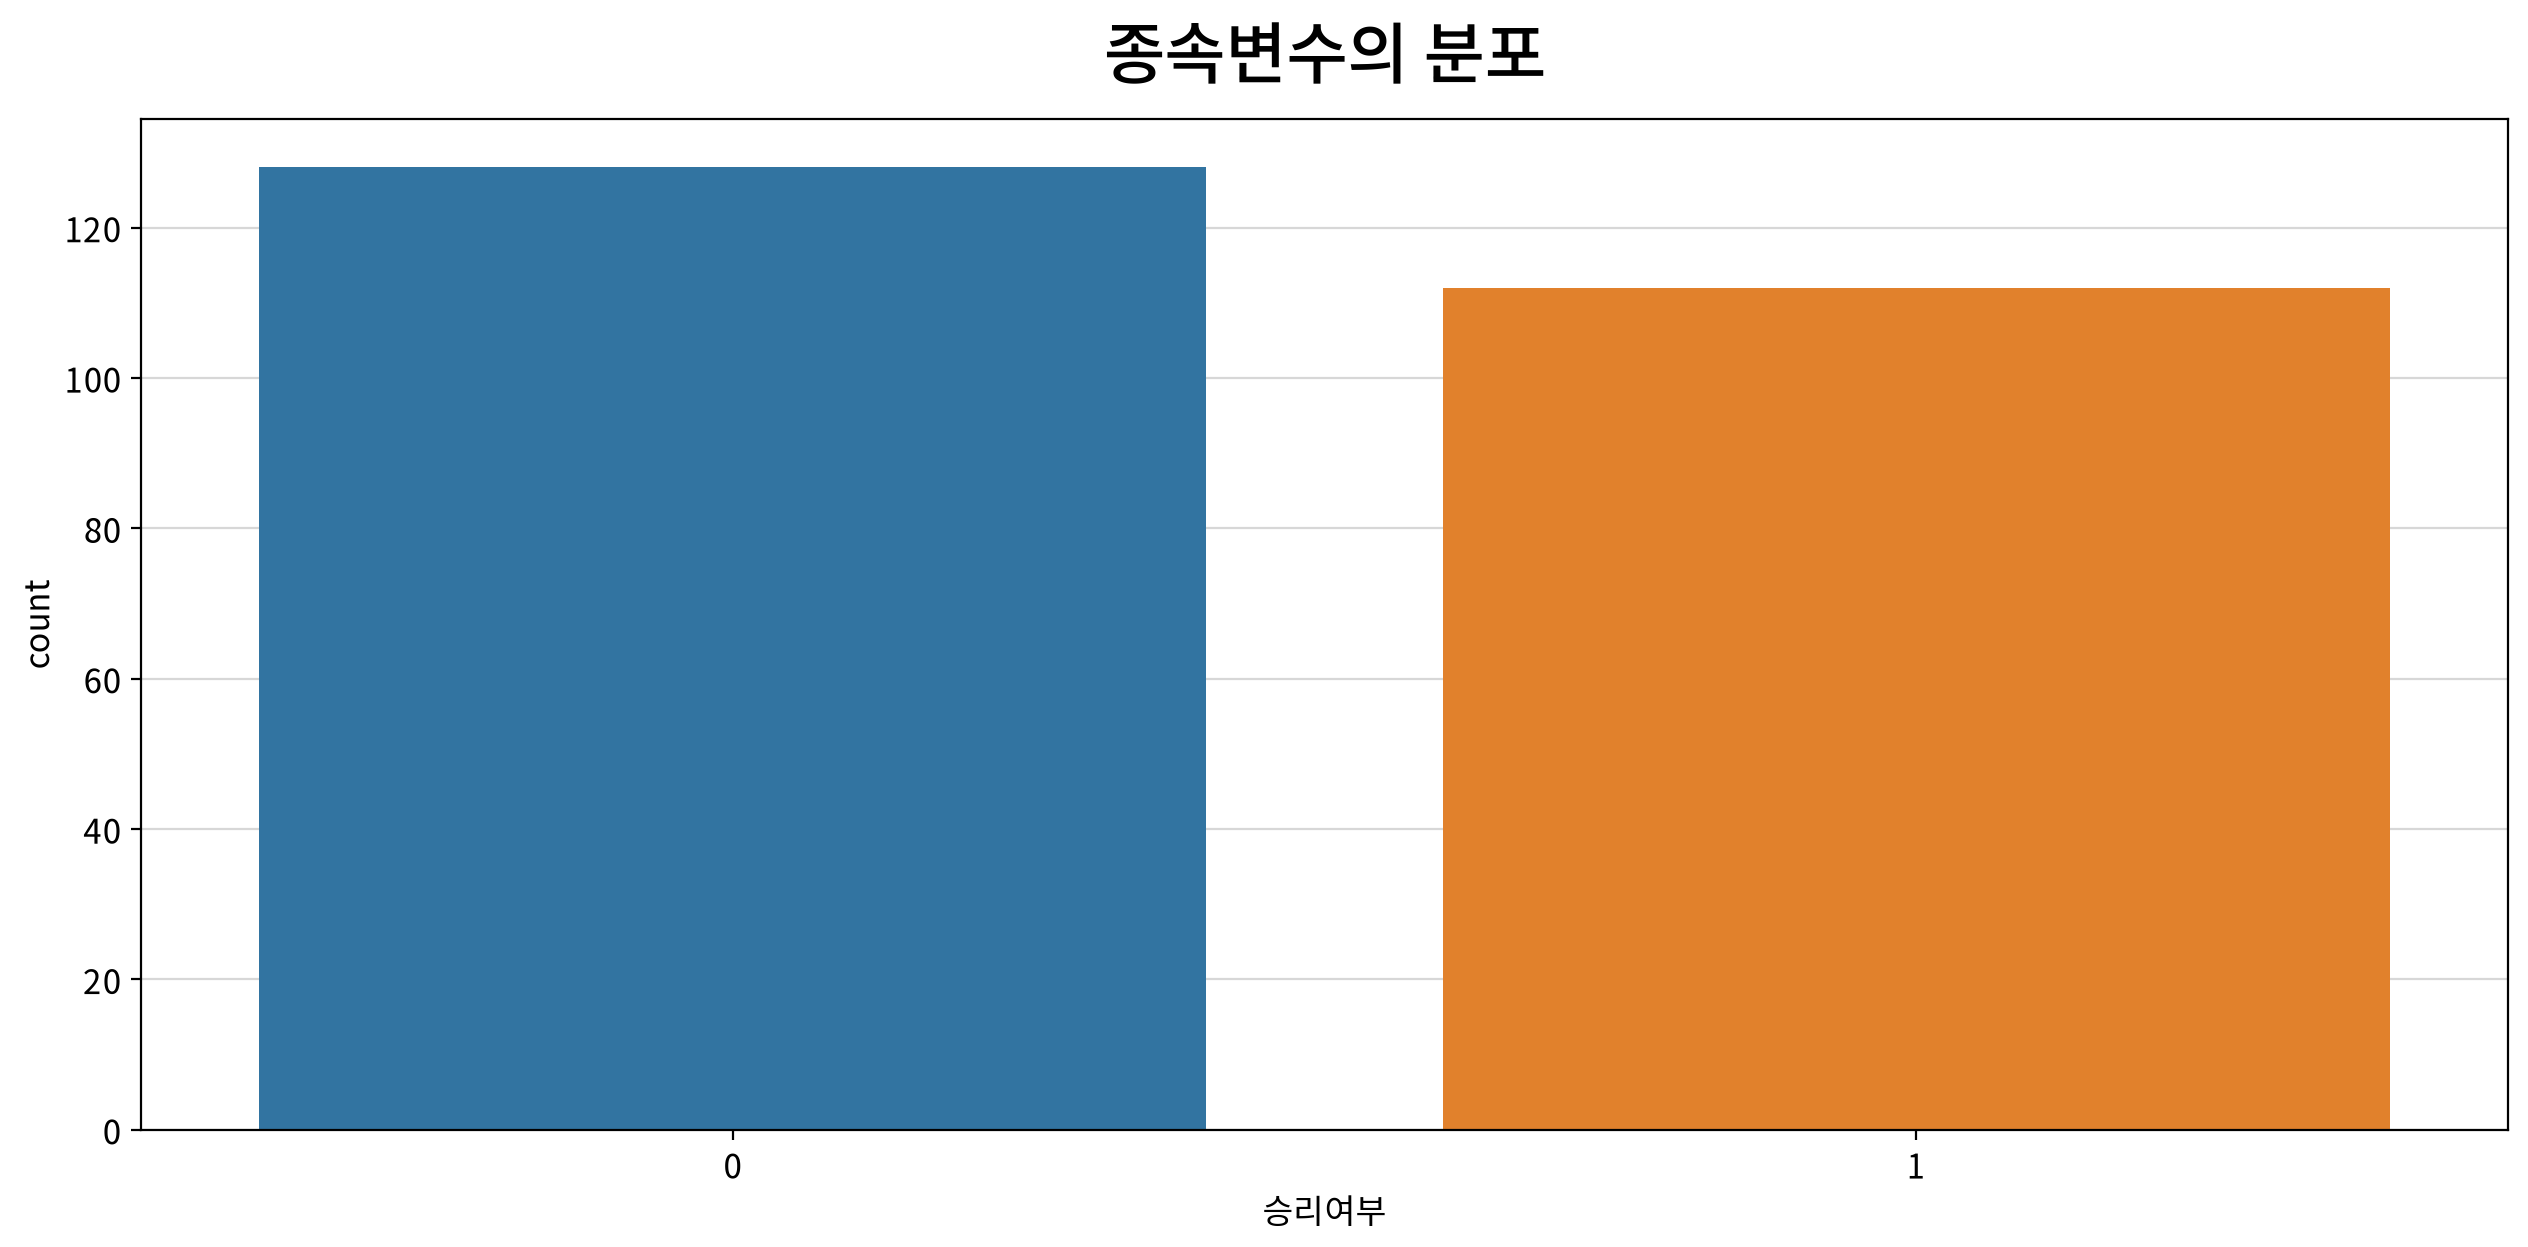

In [3]:
print(origin['승리여부'].value_counts())
my_plot.countplot(origin, x='승리여부', hue='승리여부', title='종속변수의 분포')

승리여부
0   3.766
1   2.357
Name: 실점, dtype: float64


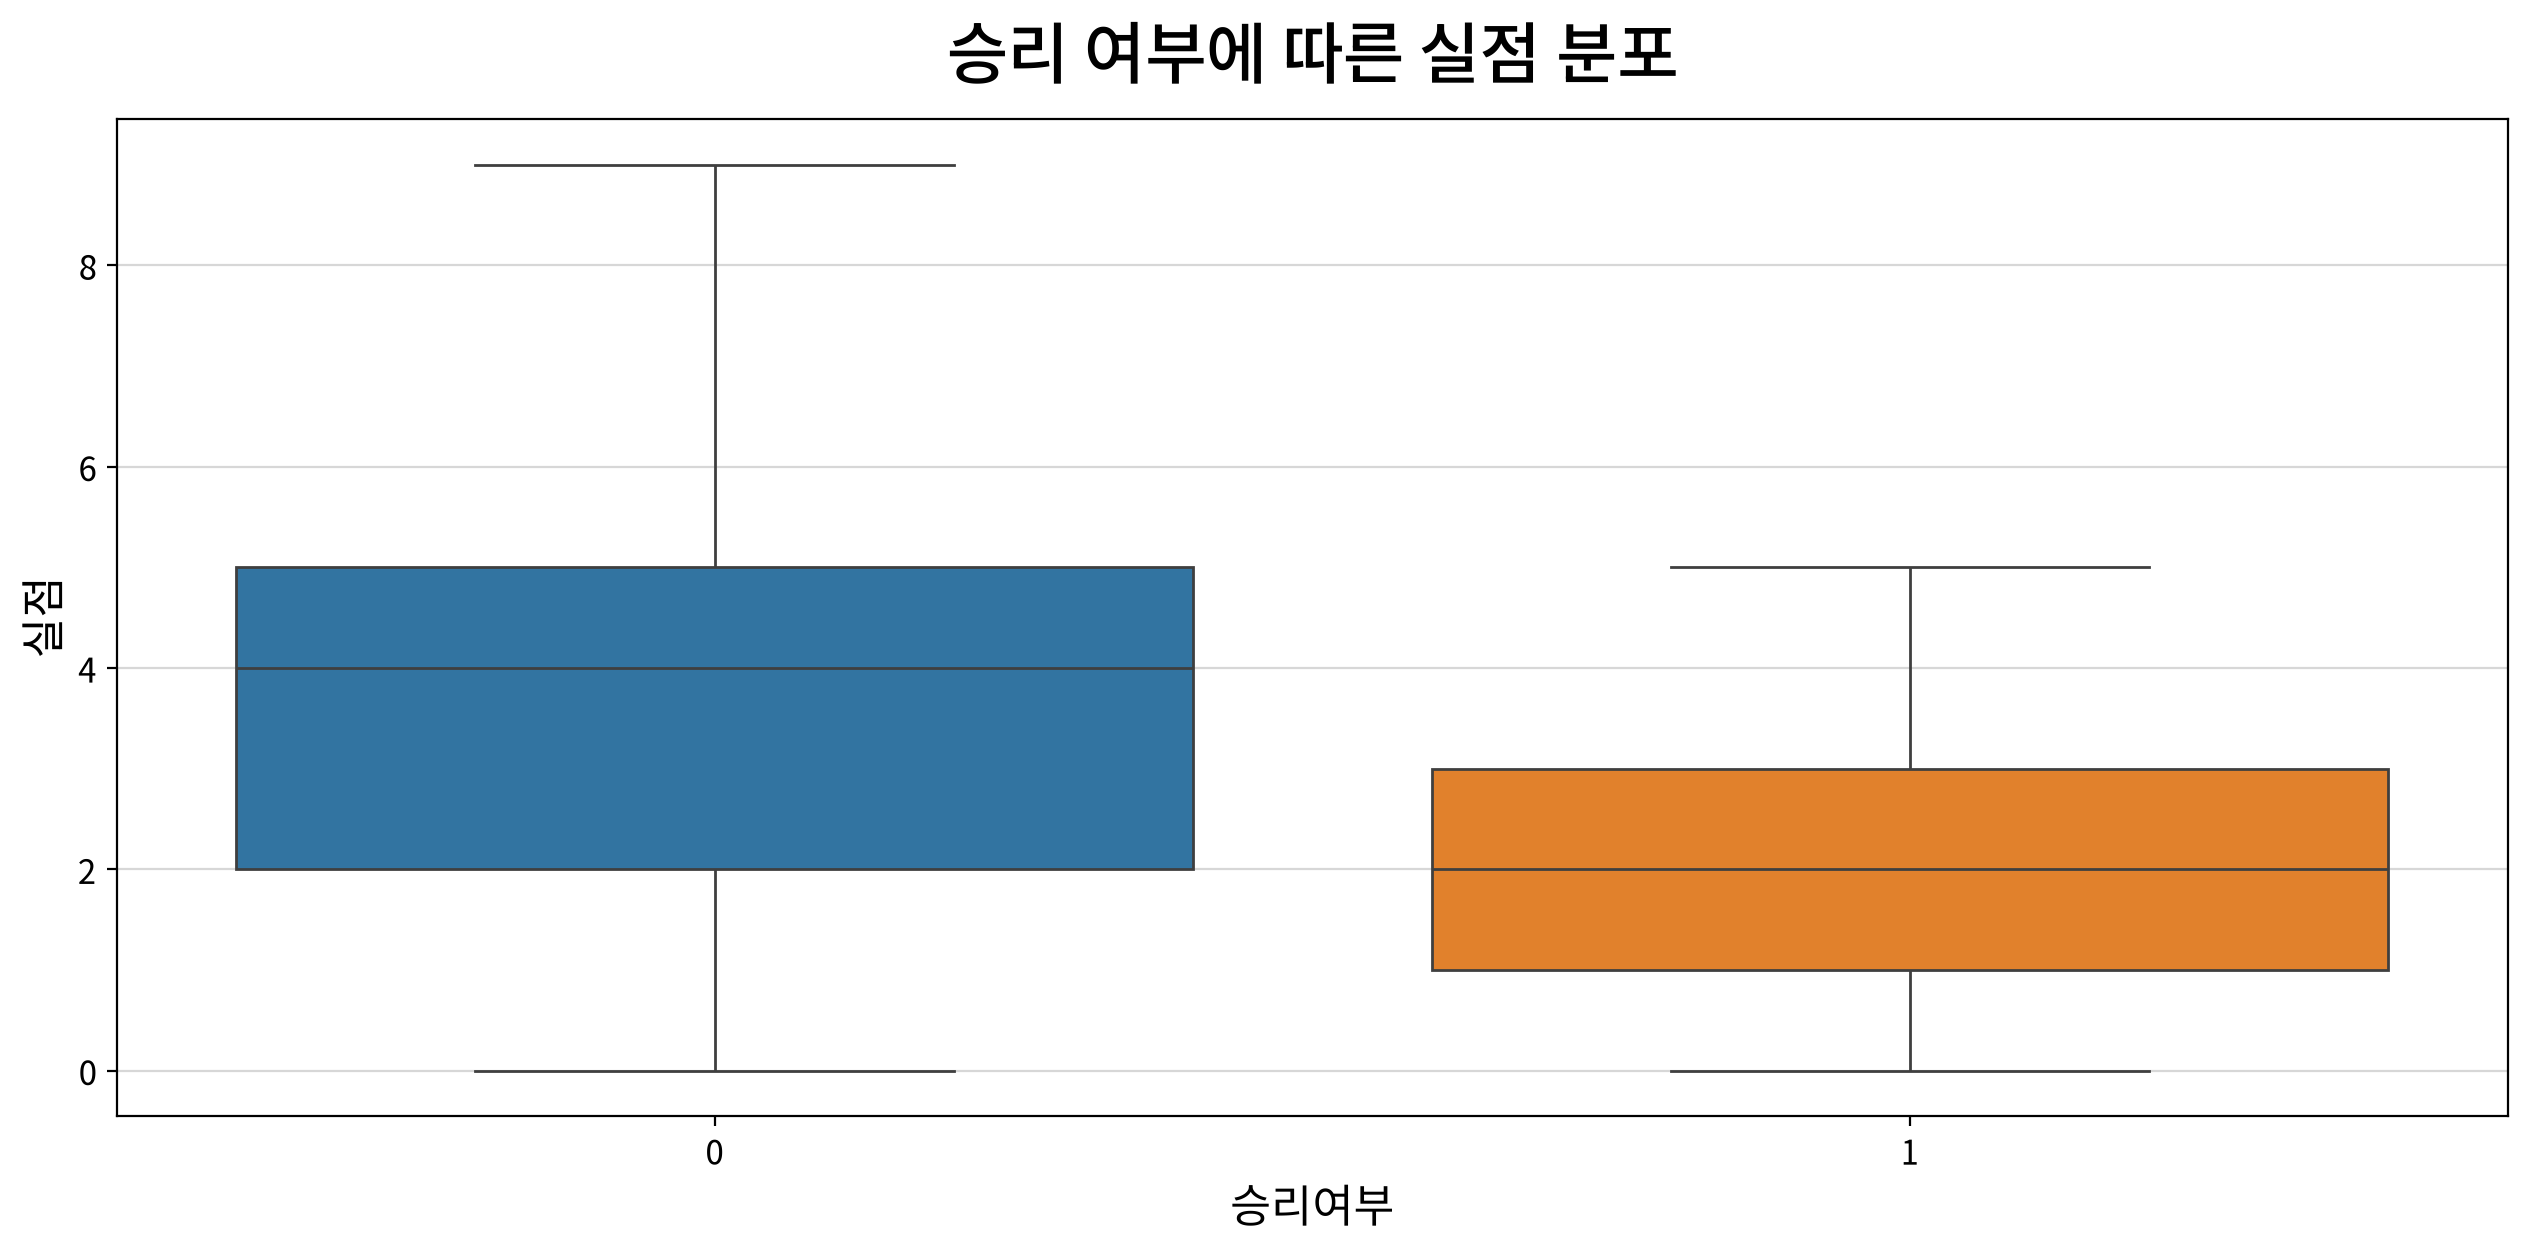

In [4]:
print(origin.groupby('승리여부')['실점'].mean())

my_plot.boxplot(origin, x='승리여부', y='실점', hue='승리여부', title='승리 여부에 따른 실점 분포', xlabel='승리여부', ylabel='실점')

### 로지스틱 모델 적합

In [5]:
fit = my_logit.fit_model(df, y='승리여부', summary=True)

NameError: name 'df' is not defined

### 예측값 생성

In [ ]:
pred = my_logit.predict(fit, df[['실점']])

new_df = df.copy()
new_df[['proba', 'pred']] = pred

new_df.head()

,실점,승리여부,proba,pred
0,4,0,0.336,0
1,1,1,0.733,1
2,3,0,0.471,0
3,3,1,0.471,0
4,2,0,0.609,1


### 시그모이드 곡선 시각화

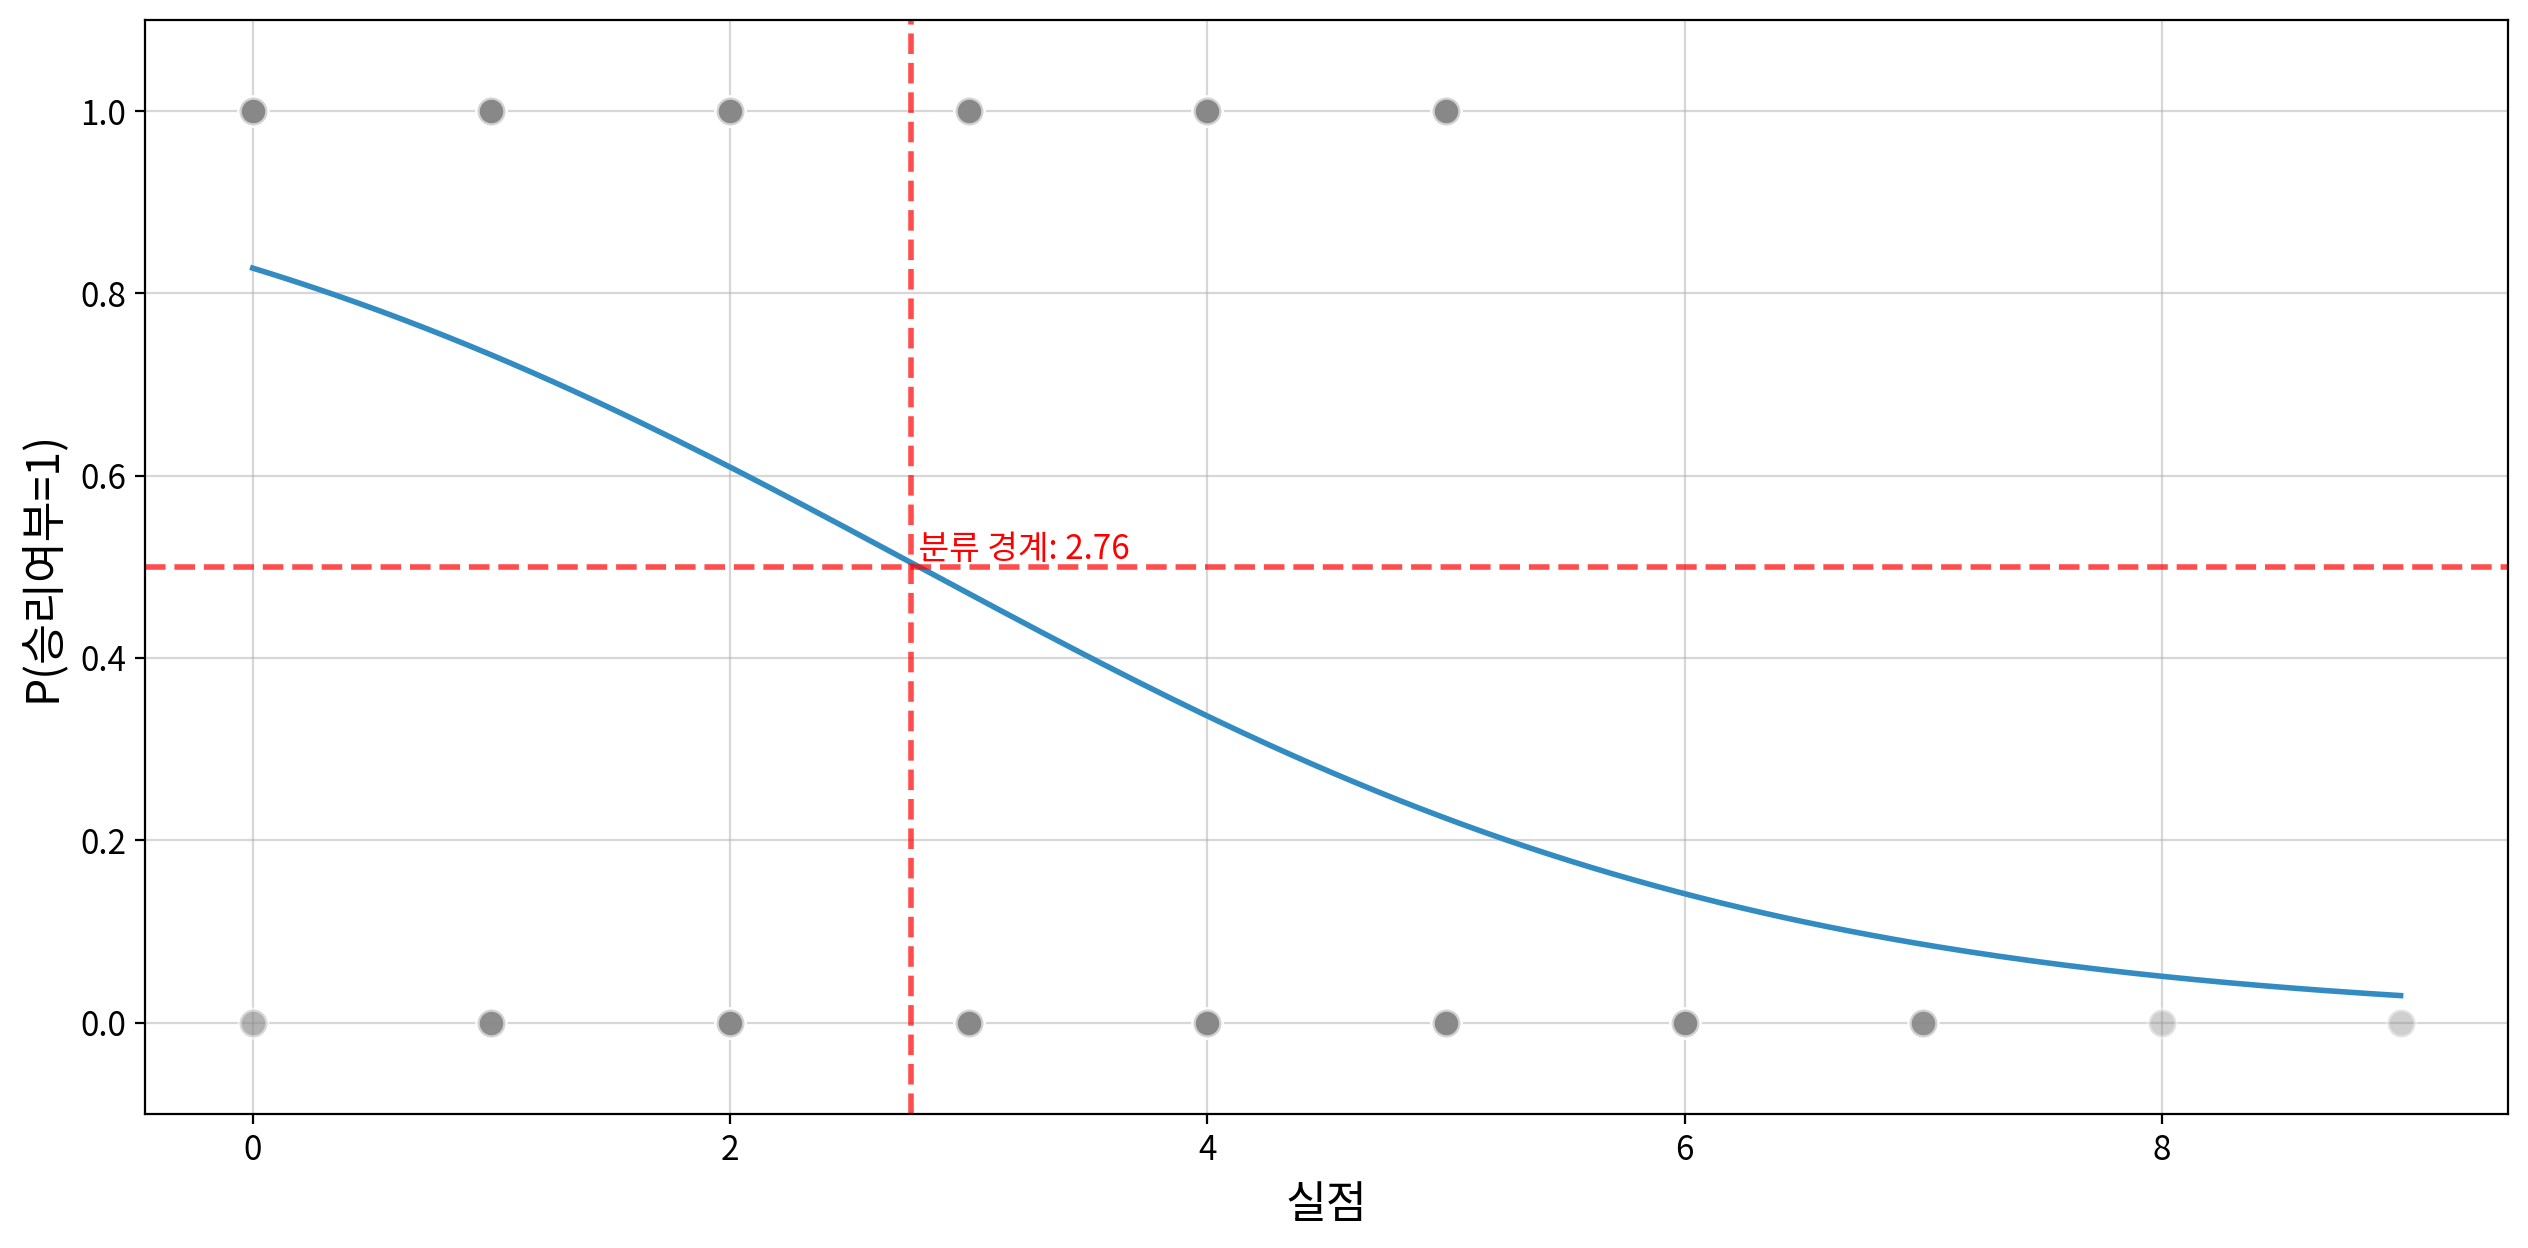

In [ ]:
my_logit.plot_sigmoid(fit, new_df, x='실점')

## 문제 풀이

### 정답 요약

| 문항 | 정답 |
|:---:|:---|
| Q1 | **0(패배), 128경기** |
| Q2 | **1 (승리한 경기)** |
| Q3 | **음수** |
| Q4 | **3점부터** |

### Q1.

종속변수 `승리여부`의 두 범주(0/1) 중 **관측치(경기 수)가 더 많은** 값은 무엇이고, 그 경기 수는 몇 경기인가?

#### 풀이: **0(패배), 128경기**

`origin['승리여부'].value_counts()` 를 실행하면 `0 → 128`, `1 → 112` 가 나온다. `countplot`의 막대 높이로도 0쪽이 더 높음을 확인할 수 있다. 종속변수가 한쪽으로 심하게 치우치지 않아(패 128 / 승 112) 분류 모형을 만들기에 적절한 균형이다.

```python
origin['승리여부'].value_counts()
```

### Q2.

승리한 경기(1)와 그렇지 못한 경기(0) 중, **평균 실점이 더 낮은** 쪽은 어느 범주인가? (0 또는 1)

#### 풀이: **1 (승리한 경기)**

`origin.groupby('승리여부')['실점'].mean()` 을 보면 패배(0)한 경기의 평균 실점은 약 **3.77점**, 승리(1)한 경기는 약 **2.36점**이다. 즉 승리한 경기의 평균 실점이 더 낮다. 앞선 `boxplot`에서 승리(1) 상자가 아래쪽(낮은 실점)에 위치하는 것과 일치한다. "적게 내줄수록 이긴다"는 가설이 데이터에 담겨 있음을 뜻한다.

```python
origin.groupby('승리여부')['실점'].mean()
```

### Q3.

적합한 로지스틱 모델에서 독립변수 `실점`의 **회귀계수(coef) 부호**는 양수인가, 음수인가?

#### 풀이: **음수**

`fit_model(..., summary=True)` 의 요약표에서 `실점` 행의 coef는 **−0.5624** 로 음수다.

### Q4.

예측 범주(`pred`)가 **승리(1)에서 패배(0)로 바뀌기 시작하는** 실점은 몇 점부터인가?

#### 풀이: **3점부터**

시그모이드 곡선의 분류 경계는 실점 ≈ **2.76점**(= −const/coef)이며, 정수 실점 기준으로는 **3점부터** 패배로 예측된다.